In [8]:
import json
import os
import random

import h5py
import numpy as np

import time
%matplotlib inline
import matplotlib.pyplot as plt

import robosuite
import imageio
from pprint import pprint   
# from lxml import etree
from utils import get_can_pos_from_old_state

In [9]:
demo_path = '../robosuite/models/assets/demonstrations/can/mh/'
hdf5_path = os.path.join(demo_path, "demo_v141.hdf5")
f = h5py.File(hdf5_path, "r")
env_args = json.loads(f["data"].attrs["env_args"])
env_name = env_args['env_name']
env_info = env_args['env_kwargs']
env_info['camera_names'] = ['frontview', 'agentview', 'birdview', 'robot0_eye_in_hand']
env_info['has_renderer'] = False
env_info['use_camera_obs'] = True
env_info['has_offscreen_renderer'] = True
env_info['camera_heights'] = 1024
env_info['camera_widths'] = 1024

In [10]:
pprint(env_info)

{'camera_depths': False,
 'camera_heights': 1024,
 'camera_names': ['frontview', 'agentview', 'birdview', 'robot0_eye_in_hand'],
 'camera_widths': 1024,
 'control_freq': 20,
 'controller_configs': {'control_delta': True,
                        'damping': 1,
                        'damping_limits': [0, 10],
                        'impedance_mode': 'fixed',
                        'input_max': 1,
                        'input_min': -1,
                        'interpolation': None,
                        'kp': 150,
                        'kp_limits': [0, 300],
                        'orientation_limits': None,
                        'output_max': [0.05, 0.05, 0.05, 0.5, 0.5, 0.5],
                        'output_min': [-0.05, -0.05, -0.05, -0.5, -0.5, -0.5],
                        'position_limits': None,
                        'ramp_ratio': 0.2,
                        'type': 'OSC_POSE',
                        'uncouple_pos_ori': True},
 'has_offscreen_renderer': True,
 'has

In [10]:
env = robosuite.make(
    env_name,
    **env_info
)

ep = 'demo_201'
states = f["data/{}/states".format(ep)][()]
actions = np.array(f["data/{}/actions".format(ep)][()])
state = states[0]
env.reset()
env.sim.set_state_from_flattened(state)
env.sim.forward()
for i, action in enumerate(actions):
    obs, reward, done, info = env.step(action)
    env.render()
    
env.close()

In [ ]:
f.close()

## Try update states

In [4]:
# list of all demonstrations episodes
demos = list(f["data"].keys())

ep = demos[2]

state_0 = f["data/{}/states".format(ep)][0]

In [5]:
# with open(f'model_xml_{ep}.xml', 'w') as file:
#     file.write(f["data/{}".format(ep)].attrs["model_file"])

In [6]:
# with open('model_xml_env.xml', 'w') as file:
#     file.write(env.sim.model.get_xml())

# with open('model_xml_env_updated.xml', 'r') as file:
#     model_xml = file.read()
# env.reset_from_xml_string(model_xml)
# env.sim.reset()

In [7]:
# with open('initial_state\'.txt', 'w') as filehandle:
#     for listitem in initial_state:
#         filehandle.write('%s\n' % listitem)

# with open('initial_state_demo.txt', 'w') as filehandle:
#     for listitem in initial_state_demo:
#         filehandle.write('%s\n' % listitem)

In [8]:
# state_num = 0
# with open(f'state_{state_num}.txt', 'w') as filehandle:
#     for listitem in f["data/{}/states".format(ep)][state_num]:
#         filehandle.write('%s\n' % listitem)

In [9]:
# with open('initial_state.txt', 'r') as filehandle:
#     initial_state = np.array([float(current_state.rstrip()) for current_state in filehandle.readlines()])

# with open('initial_state_demo.txt', 'r') as filehandle:
#     initial_state_demo = np.array([float(current_state.rstrip()) for current_state in filehandle.readlines()])

# with open('state_0.txt', 'r') as filehandle:
#     state_0 = np.array([float(current_state.rstrip()) for current_state in filehandle.readlines()])

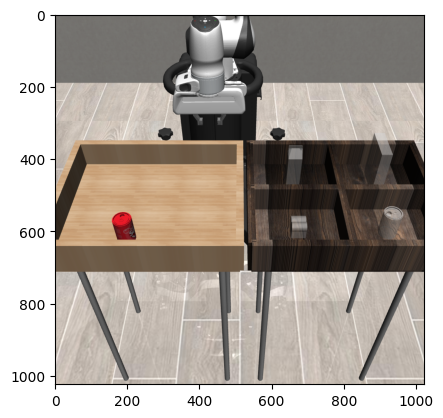

In [12]:
env_demo = robosuite.make(
    env_name,
    **env_info
)

env_demo.reset()
initial_state_demo = env_demo.sim.get_state().flatten()

env_demo.sim.set_state_from_flattened(state_0)
env_demo.sim.forward()

action_0 = f["data/{}/actions".format(ep)][0]

obs_demo, reward_demo, done_demo, info_demo = env_demo.step(action_0)
plt.imshow(obs_demo['agentview_image'][::-1, :, :])

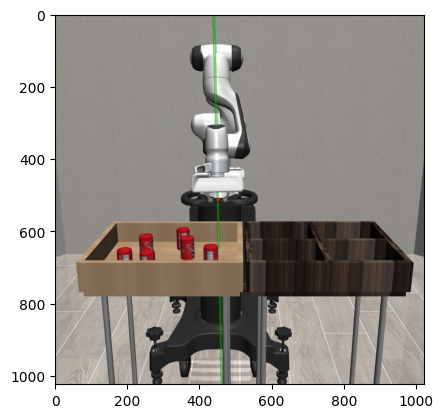

In [22]:
env = robosuite.make(
    'PickPlaceCansSingle', 
    **env_info
)

# dst_xml = etree.fromstring(env.sim.model.get_xml())
# model_xml = f["data/{}".format(ep)].attrs["model_file"]
# src_xml = etree.fromstring(model_xml)
# update_xml(dst_xml, src_xml)

# xml = env.edit_model_xml(etree.tostring(dst_xml).decode())
initial_state = env.sim.get_state().flatten()

# initial_state[0], initial_state[1:52].shape, initial_state[52:].shape
# # 1, 51, 45
# # 1, 37, 33
# # delta: 14, 18

can_pos = get_can_pos_from_old_state(state_0)

env.sim.reset()
env._reset_internal(can_pos)

obs, reward, done, info = env.step(action_0)
plt.imshow(obs['frontview_image'][::-1, :, :])

In [ ]:
can_pos

In [ ]:
list(env.object_to_id.keys())[obj_id]

In [ ]:
obj_to_use = env.objects[obj_id]
env.get_contacts(obj_to_use)

In [ ]:
for j, action in enumerate(actions):
    obs, reward, done, info = env.step(action)
    contacts = env.get_contacts(obj_to_use)
    print(j, contacts)

## Playback Demonstrations

In [ ]:
env = robosuite.make(
    'PickPlaceCansSingle', 
    **env_info
)

# list of all demonstrations episodes
demos = list(f["data"].keys())

print("Playing back random episode... (press ESC to quit)")

for i in range(5):
    ep = demos[i]
    os.path.exists(f"data/videos/demos/{ep}") or os.makedirs(f"data/videos/demos/{ep}")
    writers = [imageio.get_writer(f"data/videos/demos/{ep}/{env_name}_{camera}_video.mp4", fps=20) for camera in env_info['camera_names']]
    env.reset()
    successful = False
    observations = []
    
    # dst_xml = etree.fromstring(env.sim.model.get_xml())
    # model_xml = f["data/{}".format(ep)].attrs["model_file"]
    # src_xml = etree.fromstring(model_xml)
    # update_xml(dst_xml, src_xml)
    # xml = env.edit_model_xml(etree.tostring(dst_xml).decode())

    state = env.sim.get_state().flatten()
    states = f["data/{}/states".format(ep)][()]
    obj_id, state = update_state(state, states[0])

    # env.reset_from_xml_string(xml)
    env.sim.reset()
    env._reset_internal(obj_id)
    env.sim.set_state_from_flattened(state)
    # env.sim.forward()

    # check the states again: env.sim.get_state().flatten()
    if not np.all(np.equal(state, env.sim.get_state().flatten())):
        print("States are not equal in demo {}!".format(ep))
        break
    if env.object_id != obj_id:
        print("Object id not match in demo {}!".format(ep))
        break


    # load the actions and play them back open-loop
    actions = np.array(f["data/{}/actions".format(ep)][()])
    num_actions = actions.shape[0]

    for j, action in enumerate(actions):
        obs, reward, done, info = env.step(action)
        observations.append({camera + "_image": obs[camera + "_image"][::-1, :, :] for camera in env_info['camera_names']})
        # env.render()

        if env._check_success():
            if not successful:
                print(f"Episode {ep} finished successful after {j + 1}/{len(actions)} steps")
                successful = True
        elif j == num_actions - 1:
            print("Episode {} finished unsuccessful after {} steps".format(ep, j + 1))

        if j < num_actions - 1:
            # ensure that the actions deterministically lead to the same recorded states
            state_playback = env.sim.get_state().flatten()
            obj_id, state_data = update_state(state_playback.copy(), states[j + 1])
            if not np.all(np.equal(state_data, state_playback)):
                err = np.linalg.norm(state_data - state_playback)
                if err > 2:
                    print("State mismatch in demo {} at step {}! Error: {}".format(ep, j, err))
                    break

    if successful:
        for writer, camera in zip(writers, env_info['camera_names']):
            for obs in observations:
                frame = obs[camera + "_image"].astype(np.uint8)
                writer.append_data(frame)
    else:
        i -= 1

    [writer.close() for writer in writers]

In [ ]:
from ipywidgets import Output, GridspecLayout
from IPython import display

cameras = env_info['camera_names']
grid = GridspecLayout(5, len(cameras))

for j in range(5):
    ep = demos[j]
    for i, camera in enumerate(cameras):
        out = Output()
        with out:
            display.display(display.Video(f"data/videos/demos/{ep}/{env_name}_{camera}_video.mp4", embed=True))
        grid[j, i] = out

print(cameras)
grid

In [ ]:
# f.close()